# **Tokenizers - Edge Cases**

Choosing the best embedding model is the key to building a reliable semantic search. However, no matter the model you choose, there are some relationships which are not well captured by the embedding model.

In [1]:
# ! pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer, util

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
out_vector = sbert_model.encode("Vector search optimization")

out_vector.shape

(384,)

In [10]:
# Get the tokenizer 
sbert_tokenizer = sbert_model.tokenizer._tokenizer

print(sbert_tokenizer.get_vocab_size())

30522


### **Unknown Tokens**

Observe the following two sentences: 
1. `I feel 😊`
2. `I feel 🙁`

Are these sentences same or different?

In [11]:
sbert_tokenizer.encode("I feel 😊").tokens

['[CLS]', 'i', 'feel', '[UNK]', '[SEP]']

In [12]:
sbert_tokenizer.encode("I feel happy").tokens

['[CLS]', 'i', 'feel', 'happy', '[SEP]']

In [13]:
sbert_tokenizer.encode("I feel 🙁").tokens

['[CLS]', 'i', 'feel', '[UNK]', '[SEP]']

In [14]:
sbert_tokenizer.encode("I feel sad").tokens

['[CLS]', 'i', 'feel', 'sad', '[SEP]']

**Note:** If you are using this tokenizer on the social media data, always analyse the data to identify how many unknown characters exists.

In [15]:
# ! pip install plotly

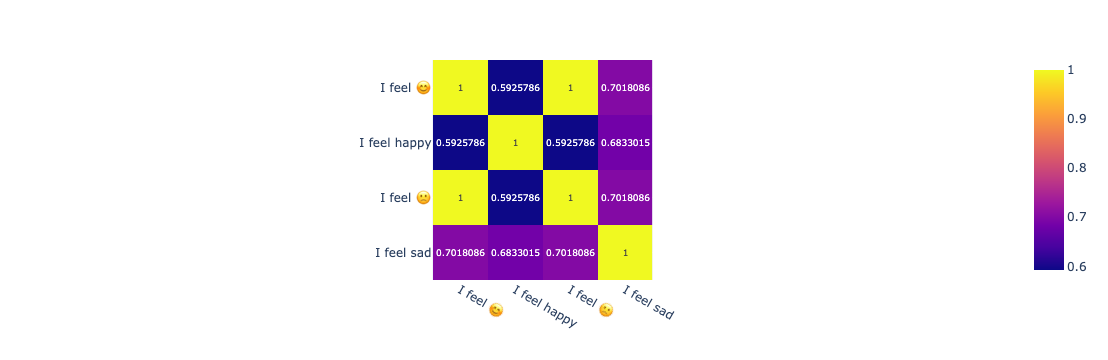

In [19]:
import plotly.express as px
from sentence_transformers import util

sentences = [
    "I feel 😊",
    "I feel happy",
    "I feel 🙁",
    "I feel sad",
]

embeddings = sbert_model.encode(sentences)

cosine_scores = util.cos_sim(embeddings, embeddings)

px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True
)

### **Typos**

- One small typo can convert the text into completely different set of tokens.
- Observe that the number of tokens are also increasing.

In [21]:
typo_sentences = [
    "Great accommodation",
    "Great acommodation",
]

for sentence in typo_sentences:
    print(sbert_tokenizer.encode(sentence).tokens)

['[CLS]', 'great', 'accommodation', '[SEP]']
['[CLS]', 'great', 'ac', '##om', '##mo', '##dation', '[SEP]']


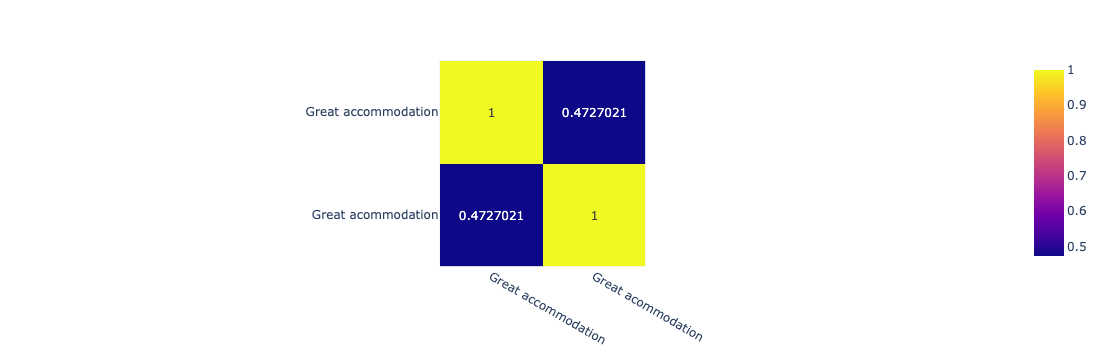

In [23]:
embeddings = sbert_model.encode(typo_sentences)

cosine_scores = util.cos_sim(embeddings, embeddings)

px.imshow(
    cosine_scores,
    x=typo_sentences,
    y=typo_sentences,
    text_auto=True,
)

### **Numerical values and date/time**

Different numerical or date/time formats used in the text can make tokenization generate different results.

In [25]:
num_sentences = [
    "This shirt costs $55.",
    "This shirt costs fifty five dollars.",
    "This shirt costs $50.",
    "This shirt costs $559.",
    "This shirt has a 10% discount from $60.",
]

for sentence in num_sentences:
    print(sbert_tokenizer.encode(sentence).tokens)

# Observe that 1st and 4th are the least similar but the tokens have maximum overlap

['[CLS]', 'this', 'shirt', 'costs', '$', '55', '.', '[SEP]']
['[CLS]', 'this', 'shirt', 'costs', 'fifty', 'five', 'dollars', '.', '[SEP]']
['[CLS]', 'this', 'shirt', 'costs', '$', '50', '.', '[SEP]']
['[CLS]', 'this', 'shirt', 'costs', '$', '55', '##9', '.', '[SEP]']
['[CLS]', 'this', 'shirt', 'has', 'a', '10', '%', 'discount', 'from', '$', '60', '.', '[SEP]']


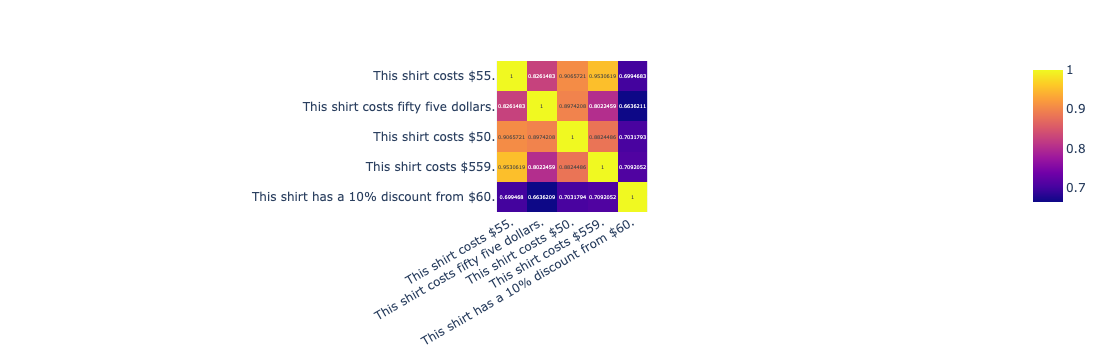

In [30]:
embeddings = sbert_model.encode(num_sentences)
cosine_scores = util.cos_sim(embeddings, embeddings)
fig = px.imshow(
    cosine_scores,
    x=num_sentences,
    y=num_sentences,
    text_auto=True,
)
fig.update_xaxes(tickangle=-30)

In [31]:
date_sentences = [
    "16th February 2024",
    "2024-02-16",
    "17th February 2024",
    "18th February 2024",
    "19th February 2024",
    "20th February 2024",
    "15th February 2024",
]

for sentence in date_sentences:
    print(sbert_tokenizer.encode(sentence).tokens)

# Observe that 1st and 2nd are similar dates but tokinized into very different results

['[CLS]', '16th', 'february', '202', '##4', '[SEP]']
['[CLS]', '202', '##4', '-', '02', '-', '16', '[SEP]']
['[CLS]', '17th', 'february', '202', '##4', '[SEP]']
['[CLS]', '18th', 'february', '202', '##4', '[SEP]']
['[CLS]', '19th', 'february', '202', '##4', '[SEP]']
['[CLS]', '20th', 'february', '202', '##4', '[SEP]']
['[CLS]', '15th', 'february', '202', '##4', '[SEP]']


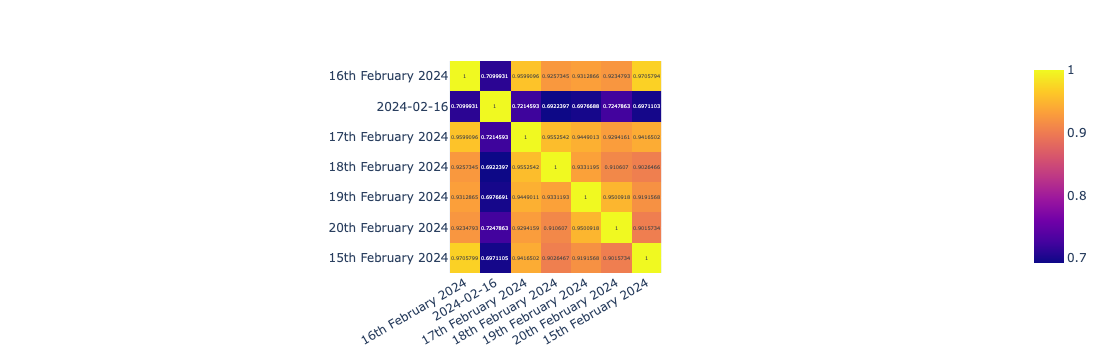

In [32]:
embeddings = sbert_model.encode(date_sentences)
cosine_scores = util.cos_sim(embeddings, embeddings)
fig = px.imshow(
    cosine_scores,
    x=date_sentences,
    y=date_sentences,
    text_auto=True,
)
fig.update_layout(
    xaxis={"type": "category"}, 
    yaxis={"type": "category"}
)
fig.update_xaxes(tickangle=-30)

### **Identifiers**

- Many businesses use specific domain terminologies.
- Observe that the number of tokens are also increasing.

In [33]:
idnt_sentences = [
    "Broadcom BCM2712",
    "Rx: Amoxicillin 500 mg caps",
    "Sig: 1 tab PO q6h PRN for pyrexia"
]

for sentence in idnt_sentences:
    print(sbert_tokenizer.encode(sentence).tokens)

['[CLS]', 'broad', '##com', 'bc', '##m', '##27', '##12', '[SEP]']
['[CLS]', 'r', '##x', ':', 'am', '##ox', '##ici', '##llin', '500', 'mg', 'caps', '[SEP]']
['[CLS]', 'si', '##g', ':', '1', 'tab', 'po', 'q', '##6', '##h', 'pr', '##n', 'for', 'p', '##yre', '##xia', '[SEP]']


## **OpenAI Tokenizer - Tiktoken**

`tiktoken` is the OpenAI fast implementation of Byte-Pair Encoding.

In [35]:
import tiktoken

# Load the tokenizer 
bpe_tokenizer = tiktoken.encoding_for_model("text-embedding-3-large")

In [36]:
print("Vocabulary Size:", bpe_tokenizer.n_vocab)

Vocabulary Size: 100277


In [40]:
sentences = [
    "I feel 😊",
    "I feel happy",
    "I feel 🙁",
    "I feel sad",
]

for sentence in sentences:
    token_ids = bpe_tokenizer.encode(sentence)
    print(bpe_tokenizer.decode_tokens_bytes(token_ids))

[b'I', b' feel', b' \xf0\x9f\x98', b'\x8a']
[b'I', b' feel', b' happy']
[b'I', b' feel', b' \xf0\x9f', b'\x99', b'\x81']
[b'I', b' feel', b' sad']
